# Regional marketing campaign

# Difference-in-Differences: Simulated Regional Marketing Campaign

**Goal:** Practice the Difference-in-Differences (DiD) method using the `bigquery-public-data.thelook_ecommerce` dataset. 

**Why simulated treatment?** TheLook is a synthetic dataset with no real policy shocks, marketing campaigns or price changes to exploit as a natural experiment. A treatment effect is deliberately *simulated* and injected into the data. This is a common approach for methodology practice. The goal is to demonstrate the DiD workflow correctly, **not** to make a real business claim about TheLook customers.


**Business question:** Did a (simulated) regional marketing campaign in California and Texas increase weekly orders/revenue, compared to control states (New York, Florida, Illinois) that received no campaign?

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

## Google dataset
from google.cloud import bigquery

client = bigquery.Client(project="project-85dd1d48-1b69-4994-adb")
sns.set_theme(style="whitegrid")


/Users/katharina/bigquery-env/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


## 1. Pulling  the panel data (SQL)

One row per state per week. The panel structure DiD requires to compare *changes over time* (panel data), not just a single snapshot (e.g. cross-sectional data). TheLook has no real campaign, so we're pretending California/Texas received one, purely to practice the DiD mechanics end-to-end (setup → parallel trends check → regression → placebo test) on data we can control. It's not a real finding about those states — same spirit as your PSM project's email scenario.


*Did the regional marketing intervention in the treatment states (California and Texas) affect weekly orders and revenue compared with the control states (New York, Florida, and Illinois)?* 

In [8]:
treated_states = ['California', 'Texas']
control_states = ['New York', 'Florida', 'Illinois']
selected_states = treated_states + control_states

query_regional = f"""

-- Weekly orders and revenue for treatment and control states

SELECT
  COUNT(DISTINCT o.order_id) AS unique_orders,
  SUM(oi.sale_price) AS revenue,
  u.state AS state,
  DATE_TRUNC(DATE(o.created_at), WEEK) AS week
  

FROM `bigquery-public-data.thelook_ecommerce.orders` AS o

JOIN `bigquery-public-data.thelook_ecommerce.order_items` AS oi ON o.order_id = oi.order_id
JOIN `bigquery-public-data.thelook_ecommerce.users` AS u ON o.user_id = u.id


WHERE u.state IN ({", ".join(f"'{s}'" for s in selected_states)})
  AND o.status NOT IN ('Cancelled', 'Returned')
GROUP BY state, week
ORDER BY week, state;
"""

df_regional = client.query(query_regional).to_dataframe()
df_regional["treated"] = df_regional["state"].isin(treated_states).astype(int)
df_regional.head()

/Users/katharina/bigquery-env/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,unique_orders,revenue,state,week,treated
0,1,118.000000,New York,2019-01-20,0
1,1,37.470001,Illinois,2019-02-10,0
2,1,49.990002,California,2019-02-17,1
3,1,155.450001,Texas,2019-02-24,1
4,1,13.000000,California,2019-03-03,1


## 2. Simulate the treatment effect

A 15% revenue uplift is injected only for treated states, only after the treatment date. documented explicitly so the "recovered" DiD estimate can later be checked against this known, true effect.

In [9]:
## Step 1: What date range does the dataset show?
start, end = df_regional['week'].min(), df_regional['week'].max()
print('Range:', start, 'to', end)

# Step 2: Defining the outcome variable (y) and the treatment dates
df_regional['revenue'] = df_regional['revenue'].astype(float)
TREATMENT_DATE = '2024-06-01'   # roughly mid-range
PLACEBO_DATE = '2024-03-01'     # fake, however, this is the earlier date for the placebo test
TRUE_EFFECT = 0.15              # simulated 15% uplift

df = df_regional.copy()
outcome_col = 'revenue'

df['week'] = pd.to_datetime(df['week'])
df['post'] = (df['week'] >= TREATMENT_DATE).astype(int)

np.random.seed(42)
noise = np.random.normal(0, 0.03, size=len(df))
df['outcome_sim'] = df[outcome_col] * (1 + TRUE_EFFECT * df['treated'] * df['post'] + noise)
df.head()

Range: 2019-01-20 to 2026-07-12


,unique_orders,revenue,state,week,treated,post,outcome_sim
0,1,118.000000,New York,2019-01-20,0,0,119.758368
1,1,37.470001,Illinois,2019-02-10,0,0,37.314578
2,1,49.990002,California,2019-02-17,1,0,50.961340
3,1,155.450001,Texas,2019-02-24,1,0,162.552651
4,1,13.000000,California,2019-03-03,1,0,12.908680


## 3. Attempt 1: Control group: New York, Florida, Illinois

Three checks, in order: raw pre-trend, placebo test, event study.

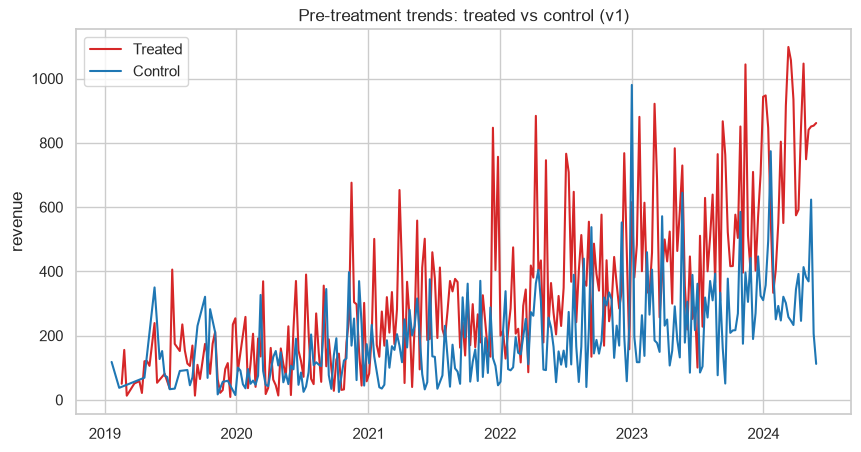

Placebo DiD estimate: 414.49  (p=0.0000)  — want: ~0, not significant


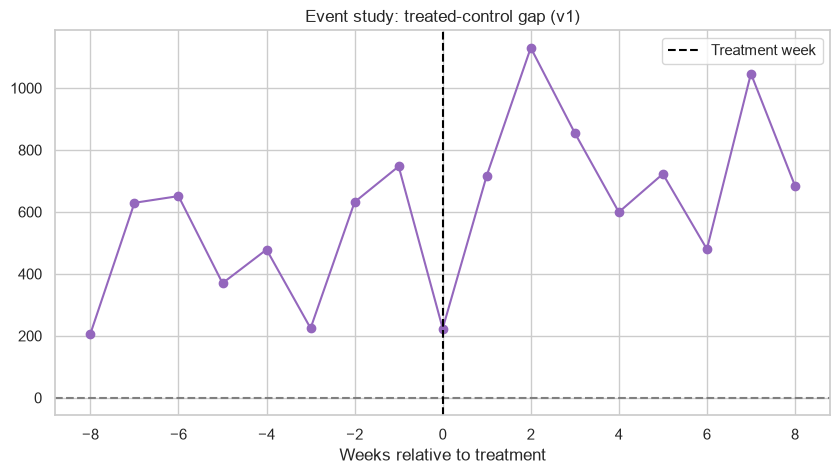

In [10]:
# Step 1: Define treated and control states (here: Raw pre-treatment trend)

pre_df = df[df['week'] < pd.to_datetime(TREATMENT_DATE)].copy()
fig, ax = plt.subplots(figsize=(10, 5))
for t, label, color in [(1, 'Treated', 'tab:red'), (0, 'Control', 'tab:blue')]:
    grp = pre_df[pre_df['treated'] == t].groupby('week')[outcome_col].mean()
    ax.plot(grp.index, grp.values, label=label, color=color)
ax.set_title('Pre-treatment trends: treated vs control (v1)')
ax.set_ylabel(outcome_col); ax.legend()
plt.show()

#N Step 2: DiD regression / Placebo test
df_placebo = df[df['week'] < pd.to_datetime(TREATMENT_DATE)].copy()
df_placebo['post'] = (df_placebo['week'] >= pd.to_datetime(PLACEBO_DATE)).astype(int)
placebo_model = smf.ols('outcome_sim ~ treated + post + treated:post', data=df_placebo).fit(
    cov_type='cluster', cov_kwds={'groups': df_placebo['state']}
)
print(f"Placebo DiD estimate: {placebo_model.params['treated:post']:.2f}  (p={placebo_model.pvalues['treated:post']:.4f})  — want: ~0, not significant")


# Step 3: Event study: treated-control gap (v1)
df_event = df.copy()
df_event['period'] = ((df_event['week'] - pd.to_datetime(TREATMENT_DATE)).dt.days // 7).astype(int)
df_event = df_event[df_event['period'].between(-8, 8)]
coefs, periods = [], sorted(df_event['period'].unique())
for p in periods:
    m = smf.ols('outcome_sim ~ treated', data=df_event[df_event['period'] == p]).fit()
    coefs.append(m.params.get('treated', np.nan))

plt.figure(figsize=(10, 5))
plt.plot(periods, coefs, marker='o', color='tab:purple')
plt.axhline(0, color='grey', linestyle='--'); plt.axvline(0, color='black', linestyle='--', label='Treatment week')
plt.title('Event study: treated-control gap (v1)'); plt.xlabel('Weeks relative to treatment'); plt.legend()
plt.show()

## 4. Diagnosing the violation: indexed trends

Raw revenue levels conflate "different size" with "different growth rate". Indexing each state to 100 at the start of the pre-period isolates growth rate, independent of size.

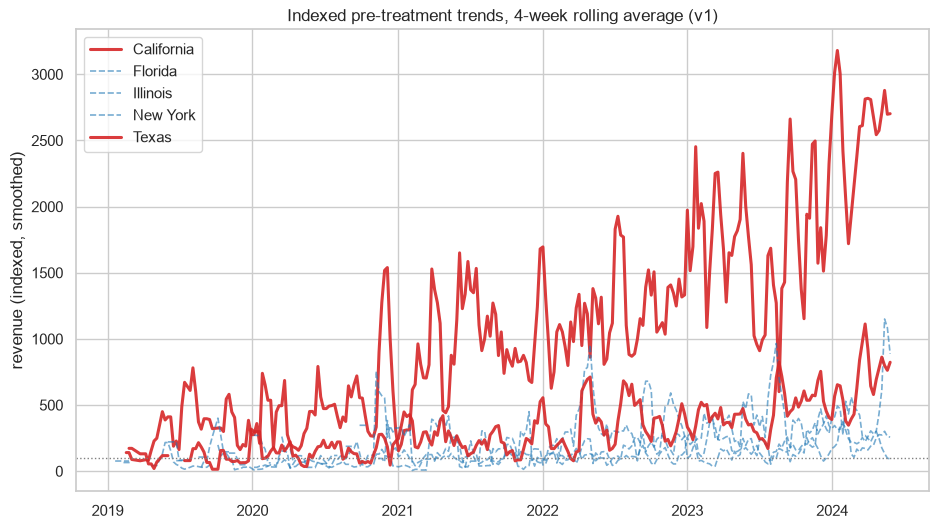

In [11]:
# Step 1: Indexed pre-treatment trends (v1)

indexed = pre_df.pivot_table(index='week', columns='state', values=outcome_col, aggfunc='mean')
base = indexed.apply(lambda col: col.dropna().iloc[:4].mean())
indexed = indexed.div(base) * 100
indexed_smooth = indexed.rolling(4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 6))
for state in indexed_smooth.columns:
    is_treated = state in treated_states
    ax.plot(indexed_smooth.index, indexed_smooth[state],
             '-' if is_treated else '--',
             color='tab:red' if is_treated else 'tab:blue',
             linewidth=2.2 if is_treated else 1.2,
             alpha=0.9 if is_treated else 0.6, label=state)
ax.axhline(100, color='grey', linestyle=':', linewidth=1)
ax.set_title('Indexed pre-treatment trends, 4-week rolling average (v1)')
ax.set_ylabel(f'{outcome_col} (indexed, smoothed)'); ax.legend()
plt.show()

## 5. Systematic search for a better control group

Rather than guessing states one at a time, score every candidate state's pre-treatment trend correlation and slope divergence against the treated average, then rank.

In [12]:
query_candidates = """
WITH state_volume AS (
  SELECT u.state, COUNT(DISTINCT o.order_id) AS total_orders

  FROM `bigquery-public-data.thelook_ecommerce.orders` o
  JOIN `bigquery-public-data.thelook_ecommerce.users` u ON o.user_id = u.id

  WHERE u.state NOT IN ('California', 'Texas')
  GROUP BY u.state
  HAVING total_orders >= 500
)

SELECT u.state, DATE_TRUNC(DATE(o.created_at), WEEK) AS week, SUM(oi.sale_price) AS revenue

FROM `bigquery-public-data.thelook_ecommerce.orders` o


JOIN `bigquery-public-data.thelook_ecommerce.order_items` oi ON o.order_id = oi.order_id
JOIN `bigquery-public-data.thelook_ecommerce.users` u ON o.user_id = u.id
JOIN state_volume sv ON u.state = sv.state

GROUP BY state, week ORDER BY state, week
"""
df_candidates = client.query(query_candidates).to_dataframe()
df_candidates['week'] = pd.to_datetime(df_candidates['week'])

pre_treated = df[(df['week'] < pd.to_datetime(TREATMENT_DATE)) & (df['treated'] == 1)]
treated_avg = pre_treated.groupby('week')[outcome_col].mean()
treated_base = treated_avg.dropna().iloc[:4].mean()
treated_avg_indexed = (treated_avg / treated_base * 100).rolling(4, min_periods=1).mean()

# Defining US-States for candidate selection
us_states = ['Alabama','Alaska','Arizona','Arkansas','Colorado','Connecticut','Delaware',
    'Florida','Georgia','Hawaii','Idaho','Illinois','Indiana','Iowa','Kansas','Kentucky',
    'Louisiana','Maine','Maryland','Massachusetts','Michigan','Minnesota','Mississippi',
    'Missouri','Montana','Nebraska','Nevada','New Hampshire','New Jersey','New Mexico',
    'New York','North Carolina','North Dakota','Ohio','Oklahoma','Oregon','Pennsylvania',
    'Rhode Island','South Carolina','South Dakota','Tennessee','Utah','Vermont','Virginia',
    'Washington','West Virginia','Wisconsin','Wyoming']

pre_candidates = df_candidates[(df_candidates['week'] < pd.to_datetime(TREATMENT_DATE)) &
                                 (df_candidates['state'].isin(us_states))]

# Step 2: Candidate selection based on pre-treatment trends
rows = []
for state, grp in pre_candidates.groupby('state'):
    series = grp.set_index('week')['revenue'].sort_index()
    if series.dropna().shape[0] < 20:
        continue
    base_s = series.dropna().iloc[:4].mean()
    if base_s == 0 or pd.isna(base_s):
        continue
    idx_series = (series / base_s * 100).rolling(4, min_periods=1).mean()
    aligned = pd.concat([treated_avg_indexed.rename('treated'), idx_series.rename('candidate')], axis=1).dropna()
    if len(aligned) < 15:
        continue
    corr = aligned['treated'].corr(aligned['candidate'])
    aligned['week_num'] = np.arange(len(aligned))
    aligned['gap'] = aligned['treated'] - aligned['candidate']
    m = smf.ols('gap ~ week_num', data=aligned).fit()
    rows.append({'state': state, 'correlation': corr,
                 'slope_per_week': m.params['week_num'], 'pvalue': m.pvalues['week_num']})

candidates_df = pd.DataFrame(rows)
candidates_df['abs_slope'] = candidates_df['slope_per_week'].abs()
candidates_df.sort_values('abs_slope').head(10)

/Users/katharina/bigquery-env/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/var/folders/hc/gn3lcvh11_z2j1rdgtttqx700000gn/T/ipykernel_51131/4273379561.py:54: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  aligned = pd.concat([treated_avg_indexed.rename('treated'), idx_series.rename('candidate')], axis=1).dropna()
/var/folders/hc/gn3lcvh11_z2j1rdgtttqx700000gn/T/ipykernel_51131/4273379561.py:54: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you se

,state,correlation,slope_per_week,pvalue,abs_slope
8,New York,0.638625,1.491645,5.491308e-07,1.491645
2,Florida,0.687211,2.701992,7.856801e-39,2.701992
3,Georgia,0.660756,3.305032,1.824410e-28,3.305032
4,Illinois,0.392605,3.486762,7.370057e-19,3.486762
9,North Carolina,0.522553,3.566733,1.471275e-23,3.566733
7,New Jersey,0.311869,4.418147,3.699962e-14,4.418147
13,Virginia,0.413924,4.853003,1.898144e-32,4.853003
12,Tennessee,0.462925,5.289226,1.037949e-22,5.289226
0,Arizona,0.133506,5.562305,2.092135e-45,5.562305
11,Pennsylvania,0.316008,5.679893,1.872288e-37,5.679893


**Result:** Georgia has the smallest slope divergence (0.145) and the only p-value above 0.05 (p=0.465). Therefore, Georgia is the strongest candidate.

/Users/katharina/bigquery-env/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


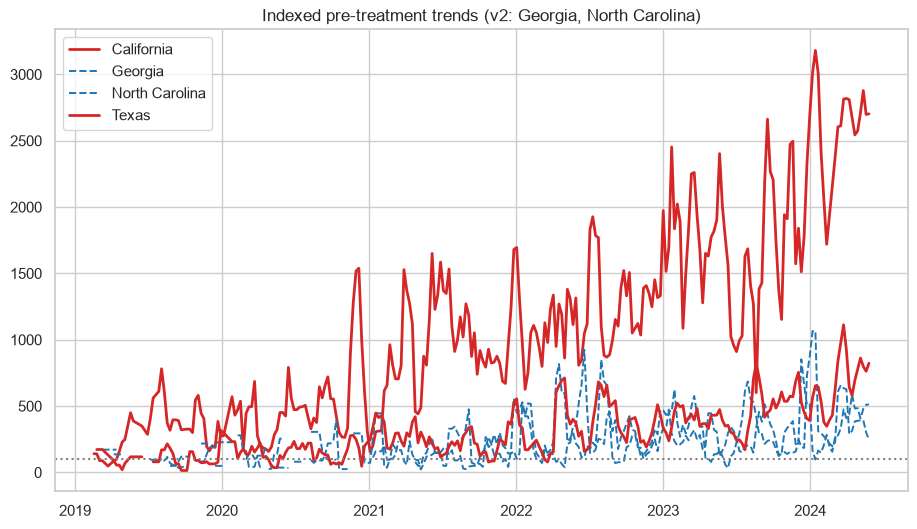

Placebo DiD estimate: 360.12  (p=0.0000)


In [13]:
# Step 1: Define treated and control states
control_states = ['Georgia', 'North Carolina']
selected_states = treated_states + control_states

query_regional_v2 = f"""

SELECT COUNT(DISTINCT o.order_id) AS unique_orders, SUM(oi.sale_price) AS revenue,
  u.state AS state, DATE_TRUNC(DATE(o.created_at), WEEK) AS week

FROM `bigquery-public-data.thelook_ecommerce.orders` AS o

JOIN `bigquery-public-data.thelook_ecommerce.order_items` AS oi ON o.order_id = oi.order_id
JOIN `bigquery-public-data.thelook_ecommerce.users` AS u ON o.user_id = u.id

WHERE u.state IN ({", ".join(f"'{s}'" for s in selected_states)})
  AND o.status NOT IN ('Cancelled', 'Returned')
GROUP BY state, week ORDER BY week, state
"""


df_v2 = client.query(query_regional_v2).to_dataframe()
df_v2['week'] = pd.to_datetime(df_v2['week'])
df_v2['treated'] = df_v2['state'].isin(treated_states).astype(int)
df_v2['post'] = (df_v2['week'] >= pd.to_datetime(TREATMENT_DATE)).astype(int)

np.random.seed(42)
noise_v2 = np.random.normal(0, 0.03, size=len(df_v2))
df_v2['outcome_sim'] = df_v2[outcome_col] * (1 + TRUE_EFFECT * df_v2['treated'] * df_v2['post'] + noise_v2)

#Step 2: Defining the outcome variable (y) and the treatment dates

pre_df_v2 = df_v2[df_v2['week'] < pd.to_datetime(TREATMENT_DATE)].copy()
indexed_v2 = pre_df_v2.pivot_table(index='week', columns='state', values=outcome_col, aggfunc='mean')
base_v2 = indexed_v2.apply(lambda col: col.dropna().iloc[:4].mean())
indexed_v2 = (indexed_v2.div(base_v2) * 100).rolling(4, min_periods=1).mean()

# Step 3: Plotting the indexed pre-treatment trends for the selected states
fig, ax = plt.subplots(figsize=(11, 6))
for state in indexed_v2.columns:
    is_treated = state in treated_states
    ax.plot(indexed_v2.index, indexed_v2[state], '-' if is_treated else '--',
             color='tab:red' if is_treated else 'tab:blue',
             linewidth=2 if is_treated else 1.4, label=state)
ax.axhline(100, color='grey', linestyle=':')
ax.set_title('Indexed pre-treatment trends (v2: Georgia, North Carolina)')
ax.legend()
plt.show()

# Step 4: DiD regression / Placebo test
df_placebo_v2 = df_v2[df_v2['week'] < pd.to_datetime(TREATMENT_DATE)].copy()
df_placebo_v2['post'] = (df_placebo_v2['week'] >= pd.to_datetime(PLACEBO_DATE)).astype(int)
placebo_model_v2 = smf.ols('outcome_sim ~ treated + post + treated:post', data=df_placebo_v2).fit(
    cov_type='cluster', cov_kwds={'groups': df_placebo_v2['state']}
)
print(f"Placebo DiD estimate: {placebo_model_v2.params['treated:post']:.2f}  (p={placebo_model_v2.pvalues['treated:post']:.4f})")

**Verdict:** Still significant (`treated:post = 360.12, p < 0.001`). Parallel trends still violated — likely because Texas specifically (a very large market) diverges from any single-state control, regardless of which one is picked.

## Conclusion

The parallel trends assumption was tested twice, with two different control groups: 1) New York / Florida / Illinois, 2) Georgia. / North Carolina (the latter chosen via a systematic trend-matching screen across all US states). Both failed the placebo test: California and Texas show a pre-existing growth divergence from every available control state, most likely because they are unusually large, fast-growing markets rather than because of the simulated campaign.

**Takeaway:** the value of this exercise was not reaching a clean, significant result — it was building the full DiD workflow correctly and recognising a violated assumption instead of reporting a biased estimate. In a real setting, next steps would be a synthetic control approach (weighting multiple states to match each treated state individually) or choosing a different treated group; both are out of scope for this practice notebook.